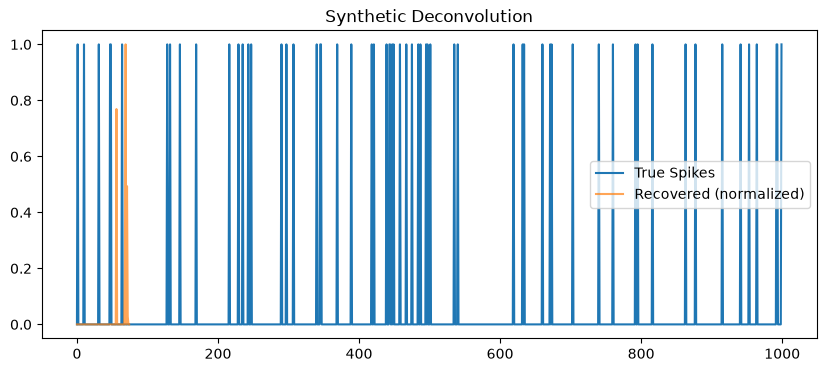

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Lasso
from scipy.signal import find_peaks
from scipy.linalg import toeplitz

# 1. Synthetic Data Generation
n_frames = 1000
fs = 15
tau = 1.0 # seconds
t_kernel = np.arange(0, 5 * tau, 1/fs)
h = np.exp(-t_kernel / tau)

# Generate spikes (Poisson ~1 Hz)
np.random.seed(42)
spikes = np.random.poisson(1/fs, n_frames)
spikes[spikes > 1] = 1 # Simple binary spikes

# Convolve to get fluorescence
fluorescence = np.convolve(spikes, h, mode='full')[:n_frames]
fluorescence += np.random.normal(0, 0.1, n_frames) # Add noise

# Solve inverse problem (Lasso)
H = toeplitz(h, np.zeros(n_frames))
H = H.T # Columns are shifted kernel
lasso = Lasso(alpha=0.002, positive=True, max_iter=10000)
lasso.fit(H, fluorescence - fluorescence.min())
recovered_spikes = lasso.coef_

# Plot synthetic validation
plt.figure(figsize=(10, 4))
plt.plot(spikes, label='True Spikes')
plt.plot(recovered_spikes / recovered_spikes.max(), label='Recovered (normalized)', alpha=0.7)
plt.legend()
plt.title('Synthetic Deconvolution')
plt.show()

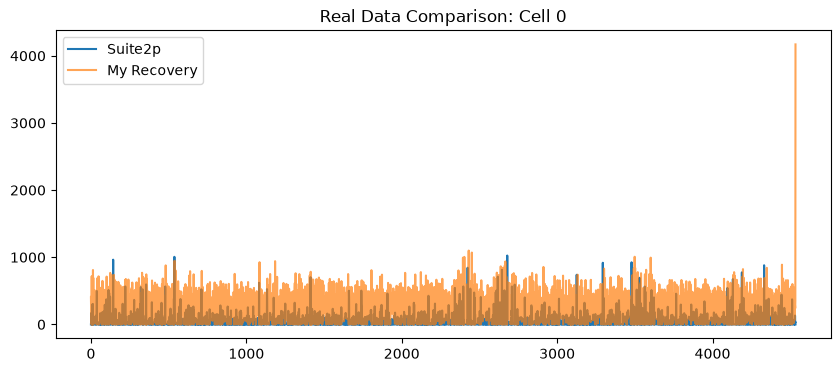

In [2]:
# 2. Apply to real data
data_dir = Path('/projectnb2/npcr25/projects/two_photon/Ex1_jRGECO1a_ResonantScanning/processed')
run_dir = data_dir / 'TSeries-03042024-run02-054'
F = np.load(run_dir / 'F.npy')
Fneu = np.load(run_dir / 'Fneu.npy')
iscell = np.load(run_dir / 'iscell.npy')
good_cells = iscell[:, 0] == 1

# Suite2p benchmark
spks_dir = Path('/projectnb2/npcr25/projects/two_photon/Ex1_jRGECO1a_ResonantScanning/Suite2P-inferred-spikes')
spks_ref = np.load(spks_dir / 'TSeries-03042024-run02-054' / 'spks.npy')

# Apply correction and deconvolute one cell
cell_idx = 0 # Example
Fc = F[cell_idx] - 0.7 * Fneu[cell_idx]
Fc -= Fc.min()

# Rebuild H for real data length
n_real = F.shape[1]
H_real = toeplitz(np.pad(h, (0, n_real - len(h))), np.zeros(n_real))
H_real = H_real.T

# Solve for this cell
lasso.fit(H_real, Fc)
spks_recovered = lasso.coef_

plt.figure(figsize=(10, 4))
plt.plot(spks_ref[cell_idx], label='Suite2p')
plt.plot(spks_recovered, label='My Recovery', alpha=0.7)
plt.legend()
plt.title(f'Real Data Comparison: Cell {cell_idx}')
plt.show()